In [1]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.integrate import solve_ivp

plt.rcParams['text.usetex'] = False


torch.manual_seed(42)
torch.set_num_threads(30)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
## Constants

# Domain Parameter
X_COLLOC_POINTS = 100
BOUNDARY_SCALE = 5
X_START = 0
X_END = 1.0 

##  Generate Domain
# Generate Collocation Points
x = torch.linspace(X_START, X_END, X_COLLOC_POINTS, device=device, requires_grad=True)


In [3]:
# EDOs to solve
def derivatives_fnc(EDO, x, u):
    if EDO == 1 :
        du_dx = - 10 * u
    elif EDO == 2: 
        lamb = 8
        kappa = 0.1
        du_dx = -lamb*u*(kappa+torch.tan(lamb*x)) 
    elif EDO == 3:
        lamb = 20
        kappa = 0.1
        du_dx = -lamb*u*(kappa+torch.tan(lamb*x)) 
    elif EDO == 4:
        du_dx = 4*u - 6*u**2 + torch.sin(50*x) + u * torch.cos(25*x) - 1/2
    return du_dx


## Create the Model
# Define QPINN
def circuit(x, basis=None):
    global map
    # Quantum Feature Map Encoding: Product Feature Map
    if map == "feature_map":
        for i in range(N_WIRES):
            qml.RY(torch.arcsin(x), wires=i)
    
    elif map == "Chebyshev_sparse":
        for i in range(N_WIRES):
            qml.RY(2 * torch.arccos(x), wires=i)

    elif map == "Chebyschev_tower":
        for i in range(N_WIRES):
            qml.RY(2 * i * torch.arccos(x), wires=i)


    # Variational Quantum Circuit: Hardware Efficient Ansatz
    for i in range(N_LAYERS):
        for j in range(N_WIRES):
            # layer of Rz-Rx-Rz rotations
            qml.RZ(theta[i,j,0], wires=j)
            qml.RX(theta[i,j,1], wires=j)
            qml.RZ(theta[i,j,2], wires=j)
    
        # for j in range(N_WIRES - 1):
        #     # entangling layer
        #     qml.CNOT(wires=[j, j + 1])

        for j in range(N_WIRES // 2):
            qml.CNOT(wires=[2*j,2*j+1]) # first layer: even wires

        for j in range((N_WIRES - 1) // 2):
            qml.CNOT(wires=[2*j+1,2*j+2]) # second layer: odd wires
 
    ## Cost Function
    ## Z-Magnetization as cost function
    return qml.expval(qml.sum(*[qml.PauliZ(i) for i in range(N_WIRES)]))  # output of the circuit is f(x)=<C>


def rescale(x):
    # Rescale input to [-0.95, 0.95] (arcsin domain)   
    delta_x = X_END - X_START    
    x_rescaled = 0.95 * 2*(x-X_START)/(X_END - X_START) - 0.95  
    # Avoid using .T on non-2D tensors (deprecated). If the tensor is 1D,
    # pass it unchanged; otherwise reverse dimensions explicitly.
    if x_rescaled.ndim == 1:
        inputs = x_rescaled
    else:
        inputs = x_rescaled.permute(*torch.arange(x_rescaled.ndim - 1, -1, -1))

    return circuit_qnode(inputs)  ## Compute the reference solution


In [4]:
def compute_MSE(EDO=1, save_pred=True):
    prediction = rescale(x)
    # Detach tensors before converting to NumPy for plotting

    if EDO == 1:
        reference_solution = torch.exp(-10*x)
    elif EDO == 2:
        lamb = 8
        kappa = 0.1
        reference_solution = torch.exp(-lamb*kappa*x)*torch.cos(lamb*x)  # u0 = 1.0

    elif EDO == 3:
        lamb = 20
        kappa = 0.1
        reference_solution = torch.exp(-lamb*kappa*x)*torch.cos(lamb*x)  # u0 = 1.0

    elif EDO == 4:
        return None

    x_np = x.detach().cpu().numpy()
    pred_np = prediction.detach().cpu().numpy()
    ref_np = reference_solution.detach().cpu().squeeze().numpy()

    mse = torch.mean((prediction - reference_solution)**2).detach().cpu().item()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x_np, pred_np, linestyle='--', label="Prediction")
    ax.plot(x_np, ref_np, label="Reference")
    ax.legend()
    ax.grid(True)
    ax.set_title(f"QPINN Prediction vs Reference Solution. MSE = {mse:.2E}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    plt.show()
    plt.close(fig)
    
    return mse  ## Define the problem

def loss_diff_fnc():
    u = rescale(x) 
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    if EDO == 1:
        res = du_dx + 10*u
    elif EDO == 2:
        lamb = 8
        kappa = 0.1
        res = du_dx + lamb*u*(kappa + torch.tan(lamb*x))
    elif EDO == 3:
        lamb = 20
        kappa = 0.1
        res = du_dx + lamb*u*(kappa + torch.tan(lamb*x))
    
    elif EDO == 4:
        res = du_dx - 4*u + 6*u**2 - torch.sin(50*x) - u * torch.cos(25*x) + 1/2
        
    return torch.mean(res**2)

def loss_boundary_fnc():
    u_0 = rescale(torch.zeros_like(x))
    return torch.mean((u_0 - 1)**2)

def loss_fnc():

    loss_diff     = loss_diff_fnc()
    loss_boundary = loss_boundary_fnc()

    return BOUNDARY_SCALE*loss_boundary + loss_diff

def closure():
    opt.zero_grad()
    l = loss_fnc()
    l.backward()
    return l  ## Benchmark different configurations


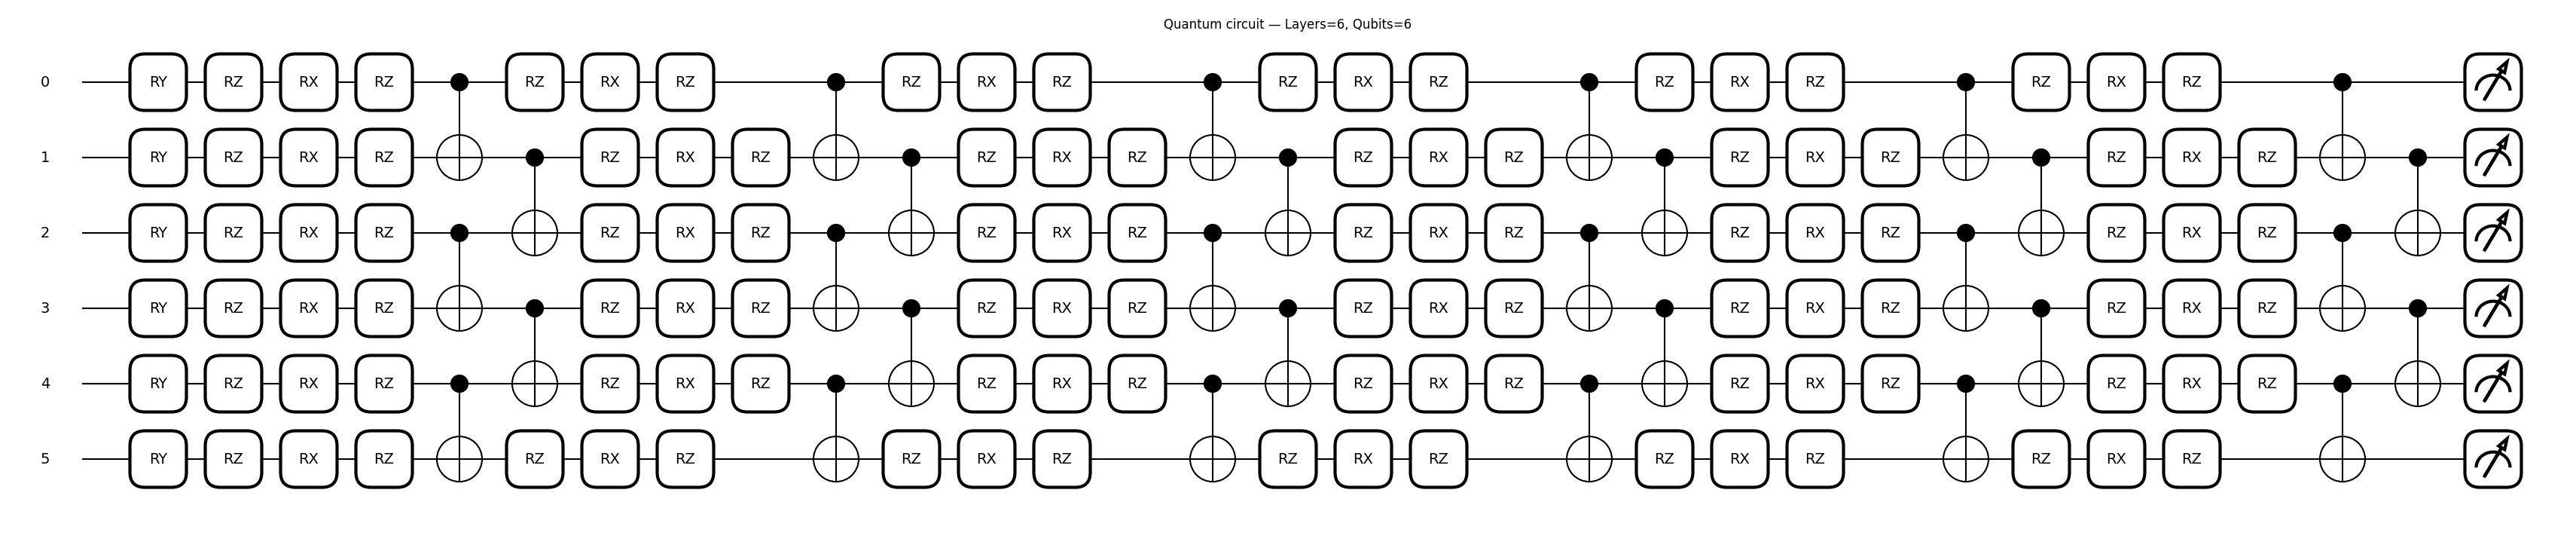

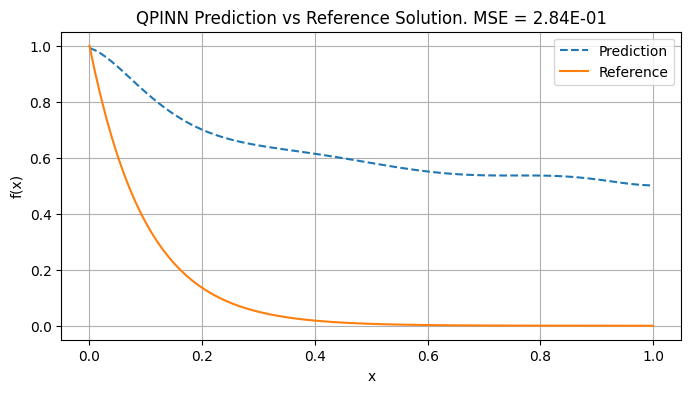

Final Loss: 6.25E-01 	 Layers: 6 	 Qubits: 6 	 MSE_ref 2.84E-01


In [5]:
tmp_loss = []
tmp_mse_ref = []
N_LAYERS = 6
N_WIRES = 6
epochs = 20
EDO = 4 # SELECT EDO HERE
map = "feature_map" # SELECT MAP HERE


circuit_qnode = qml.QNode(circuit, device=qml.device("default.qubit", wires=N_WIRES))
theta = torch.rand(N_LAYERS, N_WIRES, 3, device=device, requires_grad=True)

# Plot and save the circuit diagram for inspection
fig, ax = qml.draw_mpl(circuit_qnode)(torch.tensor(0.0))
fig.suptitle(f"Quantum circuit — Layers={N_LAYERS}, Qubits={N_WIRES}")
plt.show()
plt.close(fig)

opt = torch.optim.LBFGS([theta], line_search_fn="strong_wolfe")

previous_loss = float('inf')
loss_history = []
for epoch in range(epochs):
    opt.step(closure)
    current_loss = loss_fnc().item()
    loss_history.append(current_loss)
    print(f"Epoch {epoch}, Loss: {current_loss:.2E}", end="\r")

    if previous_loss == current_loss:
        break
    previous_loss = current_loss

final_loss = loss_fnc().item()
tmp_loss.append(final_loss)
# Plot and save loss history
fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(range(len(loss_history)), loss_history, marker='o')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title(f'Loss history — L{N_LAYERS} Q{N_WIRES} EDO{EDO}')
plt.close(fig2)

tmp_mse_ref.append(compute_MSE(EDO=EDO, save_pred=True))  
        
print(f"Final Loss: {loss_fnc().item():.2E} \t Layers: {N_LAYERS} \t Qubits: {N_WIRES} \t MSE_ref {compute_MSE():.2E}")